In [10]:
import cv2
import numpy as np
import glob

def find_lane_centers(image):
    
    threshold_value = 200
    expected_width_near = 258  # added from the graph
    expected_width_far = 163   
    
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)
    
    
    def process_row(row_pixels, expected_width):
        
        white_indices = np.where(row_pixels == 255)[0]
        
        
        left_pixels = white_indices[white_indices < 240]
        right_pixels = white_indices[white_indices >= 240]
        
        u_left = None
        u_right = None
        
        
        if len(left_pixels) > 0:
            u_left = int(np.mean(left_pixels))
            
        
        if len(right_pixels) > 0:
            u_right = int(np.mean(right_pixels))
            
        
        if u_left is not None and u_right is not None:
            # Both lines visible: center is the midpoint
            return int((u_left + u_right) / 2)
            
        elif u_left is not None:
            # Only left line visible: extrapolate using the assumed width
            return int(u_left + (expected_width / 2))
            
        elif u_right is not None:
            # Only right line visible: extrapolate backwards
            return int(u_right - (expected_width / 2))
            
        else:
            # Neither line visible (e.g., completely swallowed by shadow)
            return None

    # Apply the logic to both target rows
    u_n = process_row(thresh[260, :], expected_width_near)
    u_f = process_row(thresh[170, :], expected_width_far)
    
    return u_n, u_f


image_paths = sorted(glob.glob('C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane/**/*.png', recursive=True))
for path in image_paths:
    img = cv2.imread(path)
    if img is not None:
        un, uf = find_lane_centers(img)
        print(f"{path}: Near={un}, Far={uf}")

C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane\clear\000.png: Near=241, Far=242
C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane\clear\001.png: Near=242, Far=243
C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane\clear\002.png: Near=243, Far=244
C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane\clear\003.png: Near=244, Far=245
C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane\clear\004.png: Near=245, Far=246
C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane\clear\005.png: Near=246, Far=246
C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane\clear\006.png: Near=248, Far=247
C:/Users/vinay/OneDrive - I

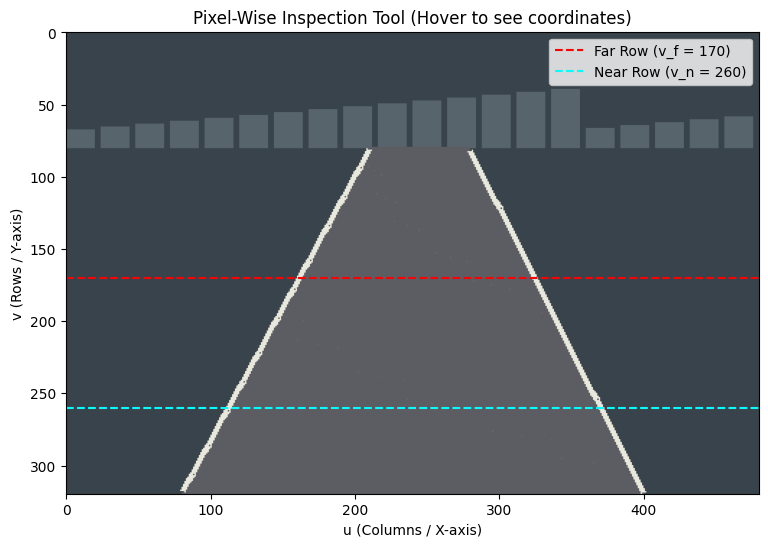

In [8]:
import cv2
import matplotlib.pyplot as plt

# Replace this with the path to one of your clear frames
image_path = r"C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane/clear/000.png"

# Read the image
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    print(f"Error: Could not load image at {image_path}. Check the file path.")
else:
    # Convert BGR (OpenCV default) to RGB (Matplotlib default) for accurate colors
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)

    # Draw horizontal lines at the target rows
    plt.axhline(y=170, color='red', linestyle='--', linewidth=1.5, label='Far Row (v_f = 170)')
    plt.axhline(y=260, color='cyan', linestyle='--', linewidth=1.5, label='Near Row (v_n = 260)')

    # Formatting the plot
    plt.title('Pixel-Wise Inspection Tool (Hover to see coordinates)')
    plt.xlabel('u (Columns / X-axis)')
    plt.ylabel('v (Rows / Y-axis)')
    plt.legend()
    
    # Show the interactive plot
    plt.show()

--- LANE DIMENSIONS ---
Near Row (v=260): Left=112, Right=370 --> Width (W_n) = 258 pixels
Far Row (v=170):  Left=161, Right=324 --> Width (W_f) = 163 pixels


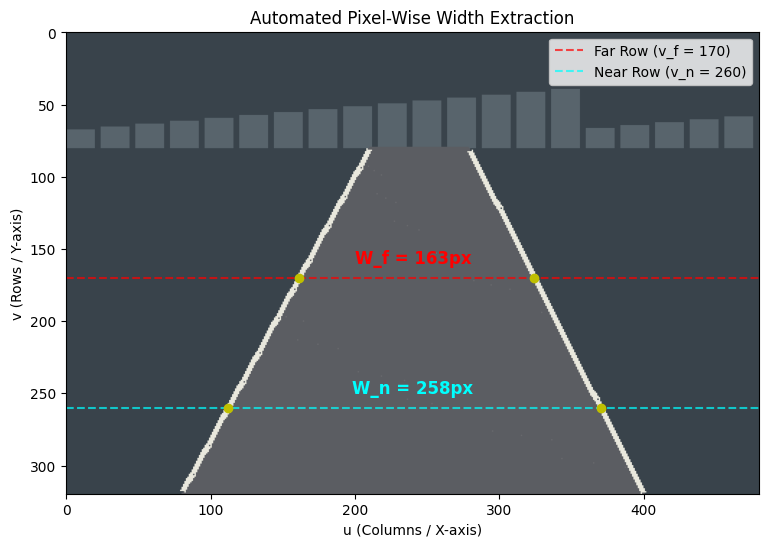

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the path to one of your clear frames
image_path = r"C:/Users/vinay/OneDrive - Indian Institute of Technology Bhubaneswar/Desktop/sedrica assignment/city/lane/clear/000.png"

# Read the image
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    print(f"Error: Could not load image at {image_path}. Check the file path.")
else:
    # --- 1. IMAGE PROCESSING TO FIND THE WIDTHS ---
    # Convert to grayscale and apply a brightness threshold
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)

    # Helper function to find lane width on a specific row
    def get_lane_width(row_pixels):
        white_indices = np.where(row_pixels == 255)[0]
        
        # Split into left side (columns 0-239) and right side (columns 240-479)
        left_pixels = white_indices[white_indices < 240]
        right_pixels = white_indices[white_indices >= 240]
        
        if len(left_pixels) > 0 and len(right_pixels) > 0:
            u_left = int(np.mean(left_pixels))
            u_right = int(np.mean(right_pixels))
            width = u_right - u_left
            return u_left, u_right, width
        return None, None, None

    # Calculate widths for both target rows
    left_n, right_n, width_n = get_lane_width(thresh[260, :])
    left_f, right_f, width_f = get_lane_width(thresh[170, :])

    # Print results to the terminal
    print(f"--- LANE DIMENSIONS ---")
    print(f"Near Row (v=260): Left={left_n}, Right={right_n} --> Width (W_n) = {width_n} pixels")
    print(f"Far Row (v=170):  Left={left_f}, Right={right_f} --> Width (W_f) = {width_f} pixels")

    # --- 2. PLOTTING ---
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)

    # Draw horizontal lines
    plt.axhline(y=170, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Far Row (v_f = 170)')
    plt.axhline(y=260, color='cyan', linestyle='--', linewidth=1.5, alpha=0.7, label='Near Row (v_n = 260)')

    # Mark the detected points and annotate the widths on the image
    if width_f is not None:
        plt.plot([left_f, right_f], [170, 170], 'yo') # Yellow dots on the lines
        plt.text(240, 160, f"W_f = {width_f}px", color='red', fontsize=12, fontweight='bold', ha='center')

    if width_n is not None:
        plt.plot([left_n, right_n], [260, 260], 'yo') # Yellow dots on the lines
        plt.text(240, 250, f"W_n = {width_n}px", color='cyan', fontsize=12, fontweight='bold', ha='center')

    # Formatting the plot
    plt.title('Automated Pixel-Wise Width Extraction')
    plt.xlabel('u (Columns / X-axis)')
    plt.ylabel('v (Rows / Y-axis)')
    plt.legend()
    
    # Show the interactive plot
    plt.show()